In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FormatStrFormatter

In [2]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = True

In [3]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', 'Phase 3', 'Only electricity', f'{subdir.lower()} climate change results.xlsx') for subdir in subdirectories]

In [4]:
GWPFilePaths

['../Results/Phase 3/Only electricity/hydrogen climate change results.xlsx',
 '../Results/Phase 3/Only electricity/carbon dioxide climate change results.xlsx',
 '../Results/Phase 3/Only electricity/ammonia climate change results.xlsx',
 '../Results/Phase 3/Only electricity/methanol climate change results.xlsx',
 '../Results/Phase 3/Only electricity/ethylene climate change results.xlsx']

In [5]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [6]:
locations = hydrogenGWPDF.sort_values('Location')['Location'].unique()

In [7]:
def replace_values(df):
    df = df.copy()
    df['Database'] = df['Database'].str.replace('Base', 'RCP6')
    df['Database'] = df['Database'].str.replace('PkBudg500', 'RCP19')
    df['Database'] = df['Database'].str.replace('PkBudg1150', 'RCP26')
    return df

hydrogenGWPDF = replace_values(hydrogenGWPDF)
# carbonDioxideGWPDF = replace_values(carbonDioxideGWPDF)
ammoniaGWPDF = replace_values(ammoniaGWPDF)
methanolGWPDF = replace_values(methanolGWPDF)
ethyleneGWPDF = replace_values(ethyleneGWPDF)

In [8]:
hydrogenGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = hydrogenGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
# carbonDioxideGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = carbonDioxideGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ammoniaGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ammoniaGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
methanolGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = methanolGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ethyleneGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ethyleneGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')

hydrogenGWPDF['Pathway'] = hydrogenGWPDF['IAM'] + ' ' + hydrogenGWPDF['SSP'] + ' ' + hydrogenGWPDF['RCP']
# carbonDioxideGWPDF['Pathway'] = carbonDioxideGWPDF['IAM'] + ' ' + carbonDioxideGWPDF['SSP'] + ' ' + carbonDioxideGWPDF['RCP']
ammoniaGWPDF['Pathway'] = ammoniaGWPDF['IAM'] + ' ' + ammoniaGWPDF['SSP'] + ' ' + ammoniaGWPDF['RCP']
methanolGWPDF['Pathway'] = methanolGWPDF['IAM'] + ' ' + methanolGWPDF['SSP'] + ' ' + methanolGWPDF['RCP']
ethyleneGWPDF['Pathway'] = ethyleneGWPDF['IAM'] + ' ' + ethyleneGWPDF['SSP'] + ' ' + ethyleneGWPDF['RCP']

In [9]:
hydrogenBAUGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, steam methane reforming of natural gas, 25 bar')]
hydrogenBlueGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains(r'hydrogen production, steam methane reforming of natural gas, with CCS \(MDEA, 98% eff.\), 25 bar')]
hydrogenWindGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity')]
hydrogenSolarGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity')]

hydrogenBAUGLOGWPDF = hydrogenBAUGWPDF[hydrogenBAUGWPDF['Location'] == 'GLO']
hydrogenBlueGLOGWPDF = hydrogenBlueGWPDF[hydrogenBlueGWPDF['Location'] == 'GLO']
hydrogenWindGLOGWPDF = hydrogenWindGWPDF[hydrogenWindGWPDF['Location'] == 'GLO']
hydrogenSolarGLOGWPDF = hydrogenSolarGWPDF[hydrogenSolarGWPDF['Location'] == 'GLO']

In [10]:
hydrogenBAUWOElecGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
hydrogenBlueWOElecGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS \(MDEA, 98% eff.\), 25 bar')]

hydrogenBAUWOElecGLOGWPDF = hydrogenBAUWOElecGWPDF[hydrogenBAUWOElecGWPDF['Location'] == 'GLO']
hydrogenBlueWOElecGLOGWPDF = hydrogenBlueWOElecGWPDF[hydrogenBlueWOElecGWPDF['Location'] == 'GLO']

In [11]:
ammoniaBAUGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia, BAU')]
ammoniaBlueGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia, blue')]
ammoniaWindGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia; hydrogen, PEM electrolysis, electricity onshore wind')]
ammoniaSolarGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia; hydrogen, PEM electrolysis, electricity solar')]

ammoniaBAUGLOGWPDF = ammoniaBAUGWPDF[ammoniaBAUGWPDF['Location'] == 'GLO']
ammoniaBlueGLOGWPDF = ammoniaBlueGWPDF[ammoniaBlueGWPDF['Location'] == 'GLO']
ammoniaWindGLOGWPDF = ammoniaWindGWPDF[ammoniaWindGWPDF['Location'] == 'GLO']
ammoniaSolarGLOGWPDF = ammoniaSolarGWPDF[ammoniaSolarGWPDF['Location'] == 'GLO']

In [12]:
methanolBAUGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol, BAU')]
methanolBlueGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol, blue')]
methanolWindGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolSolarGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

methanolBAUGLOGWPDF = methanolBAUGWPDF[methanolBAUGWPDF['Location'] == 'GLO']
methanolBlueGLOGWPDF = methanolBlueGWPDF[methanolBlueGWPDF['Location'] == 'GLO']
methanolWindGLOGWPDF = methanolWindGWPDF[methanolWindGWPDF['Location'] == 'GLO']
methanolSolarGLOGWPDF = methanolSolarGWPDF[methanolSolarGWPDF['Location'] == 'GLO']

In [13]:
ethyleneBAUGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
ethyleneBlueGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, blue')]
ethyleneWindGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
ethyleneSolarGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

ethyleneBAUGLOGWPDF = ethyleneBAUGWPDF[ethyleneBAUGWPDF['Location'] == 'GLO']
ethyleneBlueGLOGWPDF = ethyleneBlueGWPDF[ethyleneBlueGWPDF['Location'] == 'GLO']
ethyleneWindGLOGWPDF = ethyleneWindGWPDF[ethyleneWindGWPDF['Location'] == 'GLO']
ethyleneSolarGLOGWPDF = ethyleneSolarGWPDF[ethyleneSolarGWPDF['Location'] == 'GLO']

In [14]:
def plot(df, marker, facecolor, edgecolor, polycolor, ax, markerSize):
    for pathway in pathways:
        dfPathway = df.loc[df['Pathway'] == pathway].sort_values('Year')
        colorRCP = colors[dfPathway.iloc[0]['RCP']]
        colorRCPDark = colorsDark[dfPathway.iloc[0]['RCP']]
        linestyle = linestyles[dfPathway.iloc[0]['RCP']]
        IAM = dfPathway.iloc[0]['IAM']
        SSP = dfPathway.iloc[0]['SSP']
        if SSP == 'SSP2' and IAM == 'image':
            color = edgecolor
            linewidth = 1.0
        else:
            color = edgecolor
            linewidth = 0.5
        if SSP == 'SSP2':
            ax.plot(years[0:2], np.array([min(df[df['Year'] == years[0]]['GWP']), dfPathway[dfPathway['Year'] == '2030']['GWP']], dtype = object), 
                    color = color, zorder = 1, linewidth = linewidth, linestyle = linestyle)
            ax.plot(years[1:], dfPathway[dfPathway['Year'] != '2020']['GWP'], color = color, zorder = 1, linewidth = linewidth, linestyle = linestyle)
        #plt.scatter(years[0:2], np.array([min(df[df['Year'] == years[0]]['GWP']), dfPathway[dfPathway['Year'] == '2030']['GWP']], dtype = object), 
        #            facecolor = facecolor, edgecolor = edgecolor, marker = marker, s  = 15, zorder = 2)
        #plt.scatter(years[1:], dfPathway[dfPathway['Year'] != '2020']['GWP'], 
        #            facecolor = 'white', edgecolor = color, marker = marker, s  = 15, zorder = 2)

    if markerSize == 0:
        ax.scatter(years[0], min(df[df['Year'] == years[0]]['GWP']), facecolor = facecolor, edgecolor = edgecolor, marker = marker, s = 20, zorder = 2)
    else:
        ax.scatter(years[0], min(df[df['Year'] == years[0]]['GWP']), facecolor = facecolor, edgecolor = edgecolor, marker = marker, s = 20, zorder = 2)

    for x in range(0, len(years) - 1):
        dfTemp = df[df['SSP'] == 'SSP2']
        x_values = [x, x + 1, x + 1, x]
        y_values = np.array([min(dfTemp[dfTemp['Year'] == years[x]]['GWP']), min(dfTemp[dfTemp['Year'] == years[x + 1]]['GWP']), 
                            max(dfTemp[dfTemp['Year'] == years[x + 1]]['GWP']), max(dfTemp[dfTemp['Year'] == years[x]]['GWP'])])
        polygon = patches.Polygon(xy = list(zip(x_values, y_values)), facecolor = polycolor, alpha = 0.3, zorder = 0)
        ax.add_patch(polygon)

In [15]:
pathways = hydrogenBAUGWPDF['Pathway'].unique()
colors = {'RCP6' : '#fb7b71', 'RCP26' : '#e1d055', 'RCP19' : '#6abb4d'}
colorsDark = {'RCP6' : '#fa5649', 'RCP26' : '#d9c429', 'RCP19' : '#3d6f2b'}
linestyles = {'RCP6' : '-.', 'RCP26' : '-', 'RCP19' : '--'}
years = ['2020', '2030', '2040', '2050']

In [16]:
"""fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={'height_ratios': [1, 4]})
fig.subplots_adjust(hspace = 0) 

plot(hydrogenBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1)
ax1.set_ylim([9.9, 11.1])

plot(hydrogenBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2)
plot(hydrogenWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2)
plot(hydrogenSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax2.set_ylabel('GWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')

legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = 'Image\nRCP6', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = 'Image\nRCP2.6', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = 'Image\nRCP1.9', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = 'Remind\nRCP6', linewidth = 0.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = 'Remind\nRCP2.6', linewidth = 0.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = 'Remind\nRCP1.9', linewidth = 0.5),]

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 4),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend1 = fig.legend(handles = legend_elements1, frameon = False, loc = "upper center", ncol = 6, 
          prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

legend2 = fig.legend(handles = legend_elements2, frameon = False, loc = "center left", ncol = 1, 
          prop={"size":8}, bbox_to_anchor=(0.1, 0.2), handletextpad = 0.1)

for label in legend1.get_texts():
    label.set_ha('center')

for i in range(len(legend1.legend_handles)):
    handle = legend1.legend_handles[i]
    handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'GWP', 'Hydrogen SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'GWP', 'Hydrogen SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')"""

'fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={\'height_ratios\': [1, 4]})\nfig.subplots_adjust(hspace = 0) \n\nplot(hydrogenBAUGLOGWPDF, \'o\', \'#d8d8d8\', \'black\', \'#808080\', ax1)\nax1.set_ylim([9.9, 11.1])\n\nplot(hydrogenBlueGLOGWPDF, \'d\', \'#A78DD8\', \'#52318E\', \'#A78DD8\', ax2)\nplot(hydrogenWindGLOGWPDF, \'^\', \'#6DD2EA\', \'#167F99\', \'#6DD2EA\', ax2)\nplot(hydrogenSolarGLOGWPDF, \'h\', \'#FB7B71\', \'#B71205\', \'#FB7B71\', ax2)\n\nax1.spines.bottom.set_visible(False)\nax2.spines.top.set_visible(False)\nax1.xaxis.set_ticks_position(\'none\')\nax1.tick_params(labeltop = False)  # don\'t put tick labels at the top\nax2.xaxis.tick_bottom()\n\nd = 0  # proportion of vertical to horizontal extent of the slanted line\nkwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,\n              linestyle="none", color=\'k\', mec=\'k\', mew=1, clip_on=False)\nax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kw

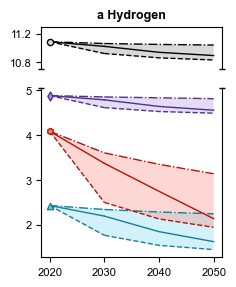

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[2]/3, fig_height*0.3), gridspec_kw={'height_ratios': [1, 4]})
fig.subplots_adjust(hspace = 0) 

plot(hydrogenBAUWOElecGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1, 30)
ax1.set_ylim([10.7, 11.3])

plot(hydrogenBlueWOElecGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2, 0)
plot(hydrogenWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(hydrogenSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.yaxis.set_major_locator(MaxNLocator(2))
ax2.yaxis.set_major_locator(MaxNLocator(4))


legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '3.5 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '2.0 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1.5),]

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

# legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
#           prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

# legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
#           prop={"size":8}, bbox_to_anchor=(0.12, 0.2), handletextpad = 0.1)

ax1.set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)

# for i in range(len(legend2.legend_handles)):
#     handle = legend2.legend_handles[i]
#     handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Hydrogen image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Hydrogen image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

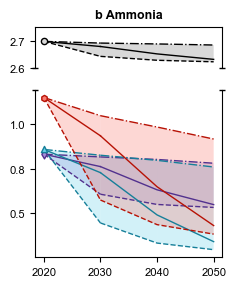

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[2]/3, fig_height*0.3), gridspec_kw={'height_ratios': [1, 4]})
fig.subplots_adjust(hspace = 0)

plot(ammoniaBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1, 30)
ax1.set_ylim([2.55, 2.78])
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(ammoniaBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2, 0)
plot(ammoniaWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(ammoniaSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.yaxis.set_major_locator(MaxNLocator(2))
ax2.yaxis.set_major_locator(MaxNLocator(4))


legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '3.5 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '2.0 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1.5),]

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

# legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
#           prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

# legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
#           prop={"size":8}, bbox_to_anchor=(0.12, 0.2), handletextpad = 0.1)

ax1.set_title('b Ammonia', fontweight = 'bold', fontsize = fontsize_title)

# for i in range(len(legend2.legend_handles)):
#     handle = legend2.legend_handles[i]
#     handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Ammonia image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Ammonia image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

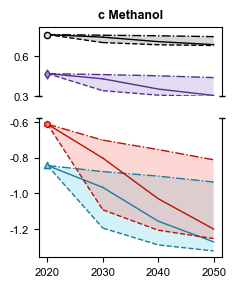

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[2]/3, fig_height*0.3), gridspec_kw={'height_ratios': [1, 2]})
fig.subplots_adjust(hspace = 0)

plot(methanolBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1, 30)
plot(methanolBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax1, 0)
ax1.set_ylim([0.3, 0.82])

plot(methanolWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(methanolSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.yaxis.set_major_locator(MaxNLocator(2))
ax2.yaxis.set_major_locator(MaxNLocator(4))

legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '3.5 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '2.0 °C', linewidth = 1.5),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1.5),]

legend_elements2 = [Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 5),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker='h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker='^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

# legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "center left", ncol = 1, 
#           prop={"size":8}, bbox_to_anchor=(0.13, 0.3), handletextpad = 0.1)

# legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
#           prop={"size":8}, bbox_to_anchor=(0.13, 0.2), handletextpad = 0.1)

ax1.set_title('c Methanol', fontweight = 'bold', fontsize = fontsize_title)

# for i in range(len(legend2.legend_handles)):
#     handle = legend2.legend_handles[i]
#     handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Methanol image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Methanol image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

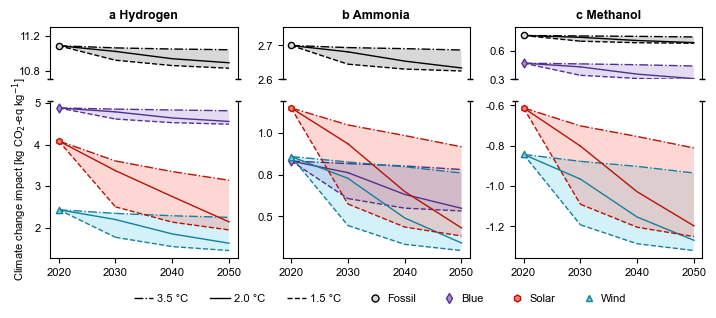

In [20]:
height_ratios = [[1, 4], [1, 2]]
fig, ax = plt.subplots(2, 3, sharex = True, figsize = (fig_length[2], fig_height*0.3), gridspec_kw={'height_ratios': [1, 3]})
fig.subplots_adjust(hspace = 0)
ax1 = ax[0,0]
ax2 = ax[1,0]
ax3 = ax[0,1]
ax4 = ax[1,1]
ax5 = ax[0,2]
ax6 = ax[1,2]

plot(hydrogenBAUWOElecGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1, 30)
ax1.set_ylim([10.7, 11.3])

plot(hydrogenBlueWOElecGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2, 0)
plot(hydrogenWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(hydrogenSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax1.yaxis.set_major_locator(MaxNLocator(2))
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_ylabel('Climate change impact [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)

plot(ammoniaBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax3, 30)
ax3.set_ylim([2.55, 2.78])
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(ammoniaBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax4, 0)
plot(ammoniaWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax4, 0)
plot(ammoniaSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax4, 0)
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.yaxis.set_major_locator(MaxNLocator(2))
ax4.yaxis.set_major_locator(MaxNLocator(4))
ax3.set_title('b Ammonia', fontweight = 'bold', fontsize = fontsize_title)

plot(methanolBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax5, 30)
plot(methanolBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax5, 0)
ax5.set_ylim([0.3, 0.85])

plot(methanolWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax6, 0)
plot(methanolSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax6, 0)
ax6.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax5.spines.bottom.set_visible(False)
ax6.spines.top.set_visible(False)
ax5.xaxis.set_ticks_position('none')
ax5.tick_params(labeltop = False)  # don't put tick labels at the top
ax6.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax5.plot([0, 1], [0, 0], transform = ax5.transAxes, **kwargs)
ax6.plot([0, 1], [1, 1], transform = ax6.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax5.yaxis.set_major_locator(MaxNLocator(2))
ax6.yaxis.set_major_locator(MaxNLocator(4))
ax5.set_title('c Methanol', fontweight = 'bold', fontsize = fontsize_title)

legend_elements =   [Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '3.5 °C', linewidth = 1),
                    Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '2.0 °C', linewidth = 1),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1),
                    Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 5),
                    Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                    Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                    Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 7, 
           prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

for i in range(len(legend.legend_handles)):
    if i < 3:
        handle = legend.legend_handles[i]
        handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'All image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'All image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

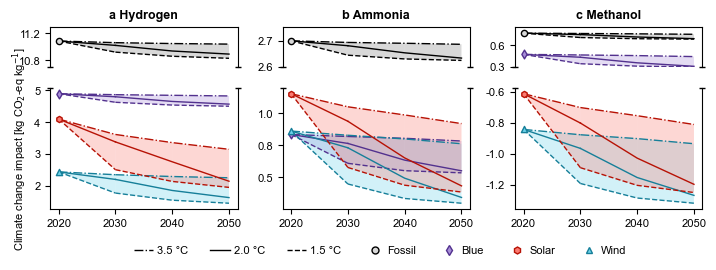

In [21]:
height_ratios = [[1, 4], [1, 2]]
fig, ax = plt.subplots(2, 3, sharex = True, figsize = (fig_length[2], fig_height*0.25), gridspec_kw={'height_ratios': [1, 3]})
fig.subplots_adjust(hspace = 0)
ax1 = ax[0,0]
ax2 = ax[1,0]
ax3 = ax[0,1]
ax4 = ax[1,1]
ax5 = ax[0,2]
ax6 = ax[1,2]

plot(hydrogenBAUWOElecGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1, 30)
ax1.set_ylim([10.7, 11.3])

plot(hydrogenBlueWOElecGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2, 0)
plot(hydrogenWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
plot(hydrogenSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.set_ticks_position('none')
ax1.tick_params(labeltop = False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

ax1.yaxis.set_major_locator(MaxNLocator(2))
ax2.yaxis.set_major_locator(MaxNLocator(4))
ax2.set_ylabel('Climate change impact [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax1.set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)

plot(ammoniaBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax3, 30)
ax3.set_ylim([2.55, 2.78])
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(ammoniaBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax4, 0)
plot(ammoniaWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax4, 0)
plot(ammoniaSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax4, 0)
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.yaxis.set_major_locator(MaxNLocator(2))
ax4.yaxis.set_major_locator(MaxNLocator(4))
ax3.set_title('b Ammonia', fontweight = 'bold', fontsize = fontsize_title)

plot(methanolBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax5, 30)
plot(methanolBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax5, 0)
ax5.set_ylim([0.3, 0.85])

plot(methanolWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax6, 0)
plot(methanolSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax6, 0)
ax6.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax5.spines.bottom.set_visible(False)
ax6.spines.top.set_visible(False)
ax5.xaxis.set_ticks_position('none')
ax5.tick_params(labeltop = False)  # don't put tick labels at the top
ax6.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax5.plot([0, 1], [0, 0], transform = ax5.transAxes, **kwargs)
ax6.plot([0, 1], [1, 1], transform = ax6.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax5.yaxis.set_major_locator(MaxNLocator(2))
ax6.yaxis.set_major_locator(MaxNLocator(4))
ax5.set_title('c Methanol', fontweight = 'bold', fontsize = fontsize_title)

legend_elements =   [Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '3.5 °C', linewidth = 1),
                    Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '2.0 °C', linewidth = 1),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1),
                    Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 5),
                    Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                    Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                    Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 7, 
           prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

for i in range(len(legend.legend_handles)):
    if i < 3:
        handle = legend.legend_handles[i]
        handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'All image SSP2 GLO 2.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'All image SSP2 GLO 2.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

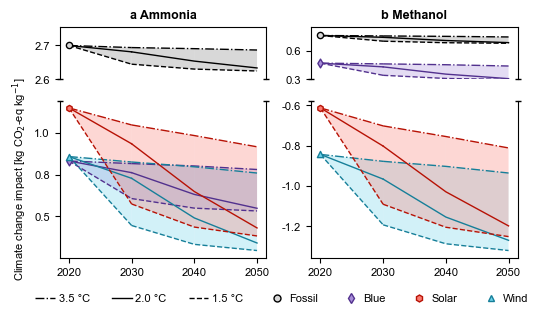

In [22]:
height_ratios = [[1, 4], [1, 2]]
fig, ax = plt.subplots(2, 2, sharex = True, figsize = (fig_length[1.5], fig_height*0.3), gridspec_kw={'height_ratios': [1, 3]})
fig.subplots_adjust(hspace = 0)
# ax1 = ax[0,0]
# ax2 = ax[1,0]
ax3 = ax[0,0]
ax4 = ax[1,0]
ax5 = ax[0,1]
ax6 = ax[1,1]

# plot(hydrogenBAUWOElecGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax1, 30)
# ax1.set_ylim([10.7, 11.3])

# plot(hydrogenBlueWOElecGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax2, 0)
# plot(hydrogenWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
# plot(hydrogenSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)

# ax1.spines.bottom.set_visible(False)
# ax2.spines.top.set_visible(False)
# ax1.xaxis.set_ticks_position('none')
# ax1.tick_params(labeltop = False)  # don't put tick labels at the top
# ax2.xaxis.tick_bottom()

# d = 0  # proportion of vertical to horizontal extent of the slanted line
# kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
#               linestyle="none", color='k', mec='k', mew=1, clip_on=False)
# ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
# ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

# ax1.yaxis.set_major_locator(MaxNLocator(2))
# ax2.yaxis.set_major_locator(MaxNLocator(4))
ax4.set_ylabel('Climate change impact [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
# ax1.set_title('a Hydrogen', fontweight = 'bold', fontsize = fontsize_title)

plot(ammoniaBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax3, 30)
ax3.set_ylim([2.55, 2.78])
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot(ammoniaBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax4, 0)
plot(ammoniaWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax4, 0)
plot(ammoniaSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax4, 0)
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax3.spines.bottom.set_visible(False)
ax4.spines.top.set_visible(False)
ax3.xaxis.set_ticks_position('none')
ax3.tick_params(labeltop = False)  # don't put tick labels at the top
ax4.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax3.plot([0, 1], [0, 0], transform = ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform = ax4.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax3.yaxis.set_major_locator(MaxNLocator(2))
ax4.yaxis.set_major_locator(MaxNLocator(4))
ax3.set_title('a Ammonia', fontweight = 'bold', fontsize = fontsize_title)

plot(methanolBAUGLOGWPDF, 'o', '#d8d8d8', 'black', '#808080', ax5, 30)
plot(methanolBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#A78DD8', ax5, 0)
ax5.set_ylim([0.3, 0.85])

plot(methanolWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax6, 0)
plot(methanolSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax6, 0)
ax6.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

ax5.spines.bottom.set_visible(False)
ax6.spines.top.set_visible(False)
ax5.xaxis.set_ticks_position('none')
ax5.tick_params(labeltop = False)  # don't put tick labels at the top
ax6.xaxis.tick_bottom()

d = 0  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax5.plot([0, 1], [0, 0], transform = ax5.transAxes, **kwargs)
ax6.plot([0, 1], [1, 1], transform = ax6.transAxes, **kwargs)

# ax2.set_ylabel('Climate change impact\n[kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
ax5.yaxis.set_major_locator(MaxNLocator(2))
ax6.yaxis.set_major_locator(MaxNLocator(4))
ax5.set_title('b Methanol', fontweight = 'bold', fontsize = fontsize_title)

legend_elements =   [Line2D([0], [0], color = "#000000", linestyle = "-.",
                                             label = '3.5 °C', linewidth = 1),
                    Line2D([0], [0], color = "#000000", linestyle = "-",
                                             label = '2.0 °C', linewidth = 1),
                    Line2D([0], [0], color = "#000000", linestyle = "--",
                                             label = '1.5 °C', linewidth = 1),
                    Line2D([0], [0], marker = 'o', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 5),
                    Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                    Line2D([0], [0], marker = 'h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                    Line2D([0], [0], marker = '^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

legend = fig.legend(handles = legend_elements, frameon = False, loc = "upper center", ncol = 7, 
           prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

for i in range(len(legend.legend_handles)):
    if i < 3:
        handle = legend.legend_handles[i]
        handle.set_xdata([0, 4, 14])

plotPathPNG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Conf all image SSP2 GLO.png')
plotPathSVG = os.path.join('..', 'Plots', 'Phase 3', 'Only electricity', 'Conf all image SSP2 GLO.svg')
plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

In [23]:
# fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (fig_length[1.5], fig_height*0.4), gridspec_kw={'height_ratios': [2, 4]})
# fig.subplots_adjust(hspace = 0)

# plot(ethyleneBAUGLOGWPDF, 'p', '#d8d8d8', 'black', '#808080', ax1, 50)
# plot(ethyleneBlueGLOGWPDF, 'd', '#A78DD8', '#52318E', '#808080', ax1, 0)
# ax1.set_ylim([0.8, 2.3])
# ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# plot(ethyleneWindGLOGWPDF, '^', '#6DD2EA', '#167F99', '#6DD2EA', ax2, 0)
# plot(ethyleneSolarGLOGWPDF, 'h', '#FB7B71', '#B71205', '#FB7B71', ax2, 0)

# ax1.spines.bottom.set_visible(False)
# ax2.spines.top.set_visible(False)
# ax1.xaxis.set_ticks_position('none')
# ax1.tick_params(labeltop = False)  # don't put tick labels at the top
# ax2.xaxis.tick_bottom()


# d = 0  # proportion of vertical to horizontal extent of the slanted line
# kwargs = dict(marker=[(-1, -d), (1, d)], markersize = 5,
#               linestyle="none", color='k', mec='k', mew=1, clip_on=False)
# ax1.plot([0, 1], [0, 0], transform = ax1.transAxes, **kwargs)
# ax2.plot([0, 1], [1, 1], transform = ax2.transAxes, **kwargs)

# ax2.set_ylabel('CCI [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')

# legend_elements1 = [Line2D([0], [0], color = "#000000", linestyle = "-",
#                                              label = '3.5 °C', linewidth = 1.5),
#                     Line2D([0], [0], color = "#000000", linestyle = "-.",
#                                              label = '2.0 °C', linewidth = 1.5),
#                     Line2D([0], [0], color = "#000000", linestyle = "--",
#                                              label = '1.5 °C', linewidth = 1.5),]

# legend_elements2 = [Line2D([0], [0], marker='p', color = "none", 
#                                              markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
#                                              label = 'Fossil', markersize = 6),
#                    Line2D([0], [0], marker = 'd', color = "none", 
#                                              markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
#                                              label = 'Blue', markersize = 5),
#                    Line2D([0], [0], marker='h', color = "none", 
#                                              markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
#                                              label = 'Solar', markersize = 5),
#                    Line2D([0], [0], marker='^', color = "none", 
#                                              markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
#                                              label = 'Wind', markersize = 5),]

# legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
#           prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

# legend2 = fig.legend(handles = legend_elements1, frameon = False, loc = "center left", ncol = 1, 
#           prop={"size":8}, bbox_to_anchor=(0.13, 0.2), handletextpad = 0.1)

# for i in range(len(legend2.legend_handles)):
#     handle = legend2.legend_handles[i]
#     handle.set_xdata([0, 4, 14])

# plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'GWP', 'Ethylene image SSP2 GLO.png')
# plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'GWP', 'Ethylene image SSP2 GLO.svg')
# plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
# plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')